In [ ]:
print("Hello World!")

Hello World!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
ride_durations = np.array([12, 25, 8, 45, 30, 18, 22, 15, 37, 28])
#np.array( )  ← converts a Python list into a NumPy array


In [ ]:
print("Average :", np.mean(ride_durations), "min")
print("Longest :", np.max(ride_durations),  "min")
print("Shortest:", np.min(ride_durations),  "min")
print("Median  :", np.median(ride_durations), "min")
print("Std Dev :", round(np.std(ride_durations), 2), "min")

Average : 24.0 min
Longest : 45 min
Shortest: 8 min
Median  : 23.5 min
Std Dev : 10.88 min


In [ ]:
ride_durations * 5

25

In [ ]:
df = pd.read_csv('dataset/uber_data.csv')

In [ ]:
df.head()

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp
0,619,Airport,1.0,Trip Completed,2016-11-07 11:51:00,2016-11-07 13:00:00
1,867,Airport,1.0,Trip Completed,2016-11-07 17:57:00,2016-11-07 18:47:00
2,1807,City,1.0,Trip Completed,2016-12-07 09:17:00,2016-12-07 09:58:00
3,2532,Airport,1.0,Trip Completed,2016-12-07 21:08:00,2016-12-07 22:03:00
4,3112,City,1.0,Trip Completed,2016-07-13 08:33:16,2016-07-13 09:25:47


In [ ]:
#Number of rows and columns in dataset
df.shape

(6745, 6)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6745 entries, 0 to 6744
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Request id         6745 non-null   int64  
 1   Pickup point       6745 non-null   object 
 2   Driver id          4095 non-null   float64
 3   Status             6745 non-null   object 
 4   Request timestamp  6745 non-null   object 
 5   Drop timestamp     2831 non-null   object 
dtypes: float64(1), int64(1), object(4)
memory usage: 316.3+ KB


In [ ]:
df['Request timestamp'] = pd.to_datetime(df['Request timestamp'], errors='coerce')
df['Drop timestamp'] = pd.to_datetime(df['Drop timestamp'], errors='coerce')

In [ ]:
df['Status'].value_counts()

,count
Status,
Trip Completed,2831
No Cars Available,2650
Cancelled,1264


In [ ]:
df['Status'].value_counts(normalize= True)

,proportion
Status,
Trip Completed,0.419718
No Cars Available,0.392884
Cancelled,0.187398


In [ ]:
df.head()

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp
0,619,Airport,1.0,Trip Completed,2016-11-07 11:51:00,2016-11-07 13:00:00
1,867,Airport,1.0,Trip Completed,2016-11-07 17:57:00,2016-11-07 18:47:00
2,1807,City,1.0,Trip Completed,2016-12-07 09:17:00,2016-12-07 09:58:00
3,2532,Airport,1.0,Trip Completed,2016-12-07 21:08:00,2016-12-07 22:03:00
4,3112,City,1.0,Trip Completed,2016-07-13 08:33:16,2016-07-13 09:25:47


In [ ]:
df['RequestHour'] = df['Request timestamp'].dt.hour

In [ ]:
df['RequestHour'].value_counts().sort_index()


,count
RequestHour,
0,99
1,85
2,99
3,92
4,203
5,445
6,398
7,406
8,423


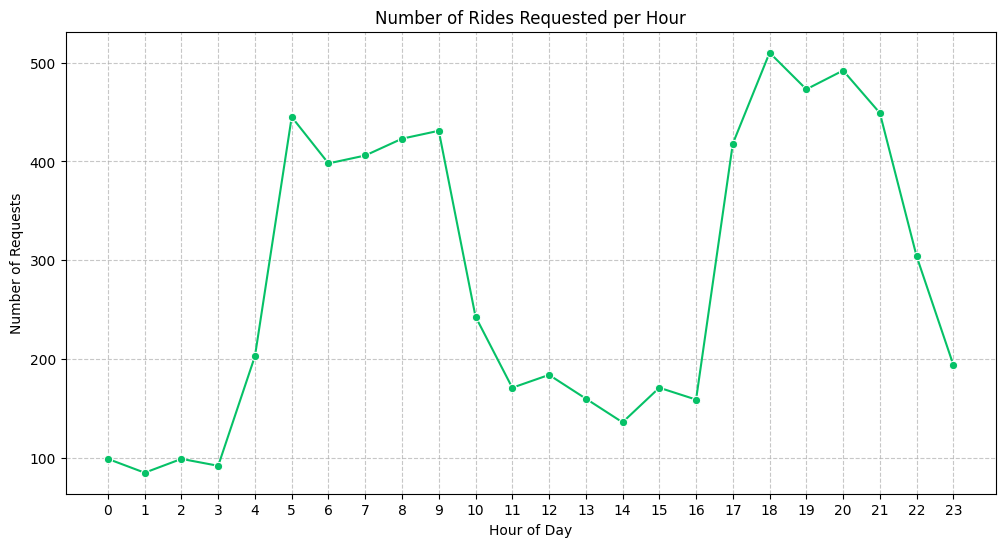

In [ ]:
rides_per_hour = df['RequestHour'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x=rides_per_hour.index, y=rides_per_hour.values, marker='o', color='#06C167')
plt.title('Number of Rides Requested per Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Requests')
plt.xticks(range(0, 24)) # Ensure all hours are displayed on the x-axis
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

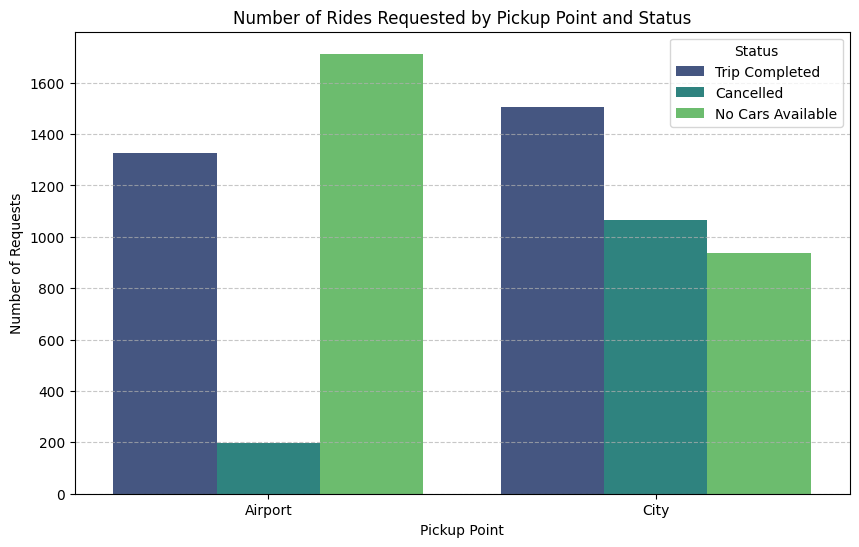

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Pickup point', hue='Status', palette='viridis')
plt.title('Number of Rides Requested by Pickup Point and Status')
plt.xlabel('Pickup Point')
plt.ylabel('Number of Requests')
plt.legend(title='Status')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
df.groupby(['RequestHour', 'Status'])['Request id'].count().unstack()

Status,Cancelled,No Cars Available,Trip Completed
RequestHour,,,
0,3,56,40
1,4,56,25
2,5,57,37
3,2,56,34
4,51,74,78
5,176,84,185
6,145,86,167
7,169,63,174
8,178,90,155


In [26]:
hourly_status = df.groupby(['RequestHour', 'Status'])['Request id'].count().unstack()

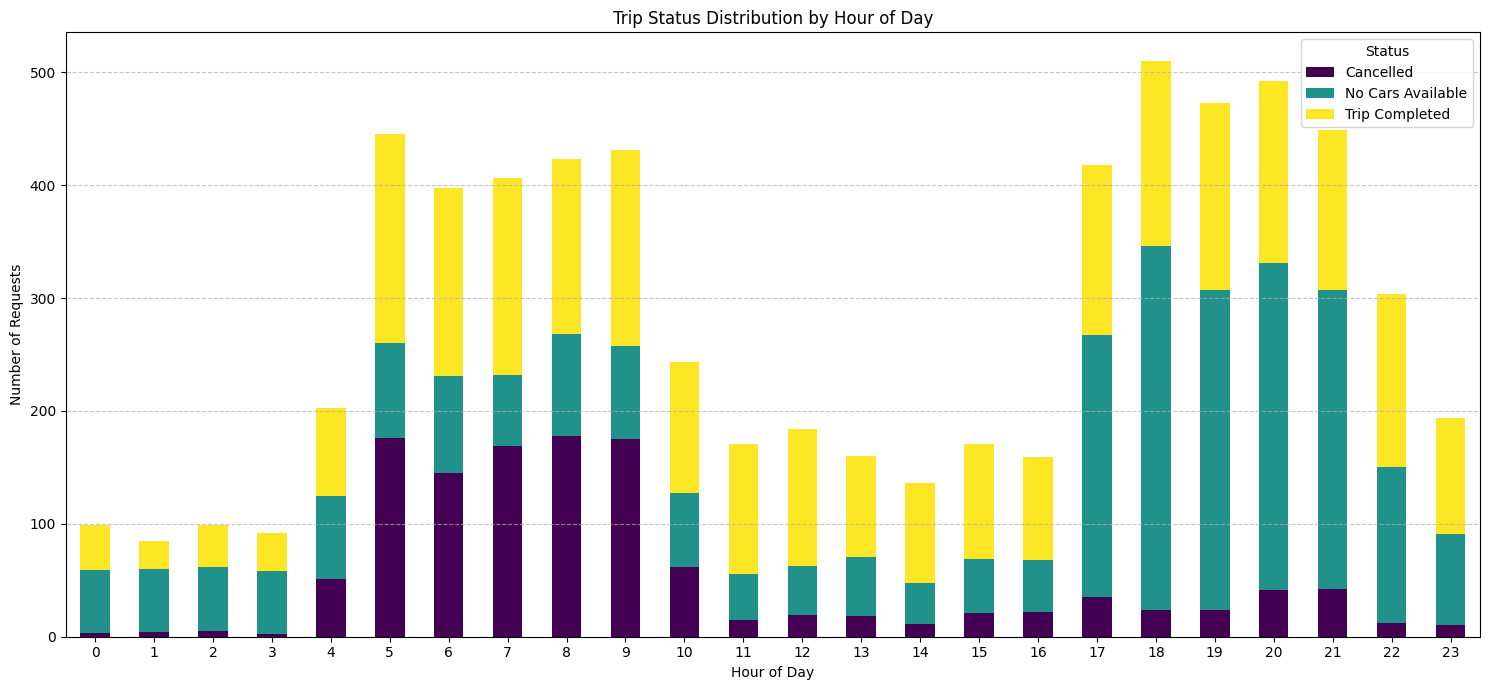

In [27]:
hourly_status.plot(kind='bar', stacked=True, figsize=(15, 7), colormap='viridis')
plt.title('Trip Status Distribution by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Requests')
plt.xticks(rotation=0)
plt.legend(title='Status')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

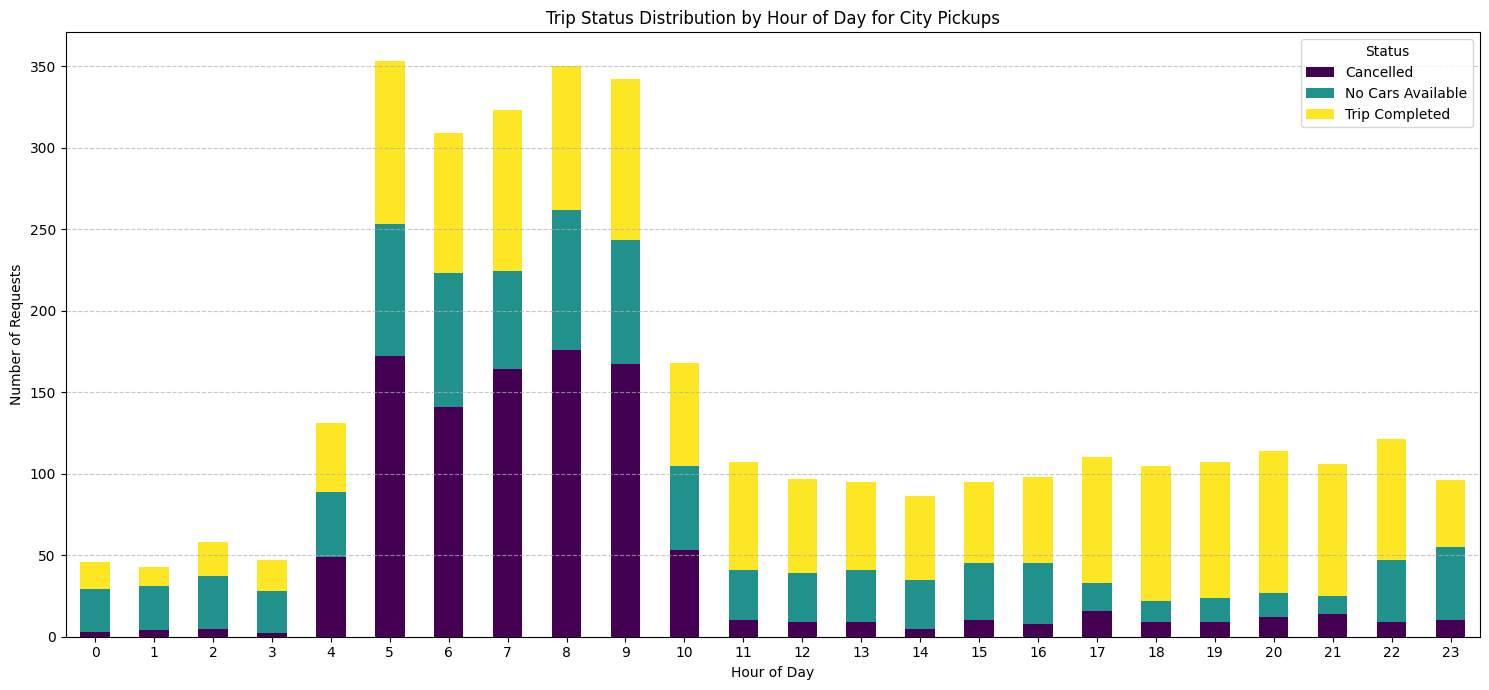

In [28]:
hourly_status_city = df[df['Pickup point'] == 'City'].groupby(['RequestHour', 'Status'])['Request id'].count().unstack().fillna(0)
hourly_status_city.plot(kind='bar', stacked=True, figsize=(15, 7), colormap='viridis')
plt.title('Trip Status Distribution by Hour of Day for City Pickups')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Requests')
plt.xticks(rotation=0)
plt.legend(title='Status')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

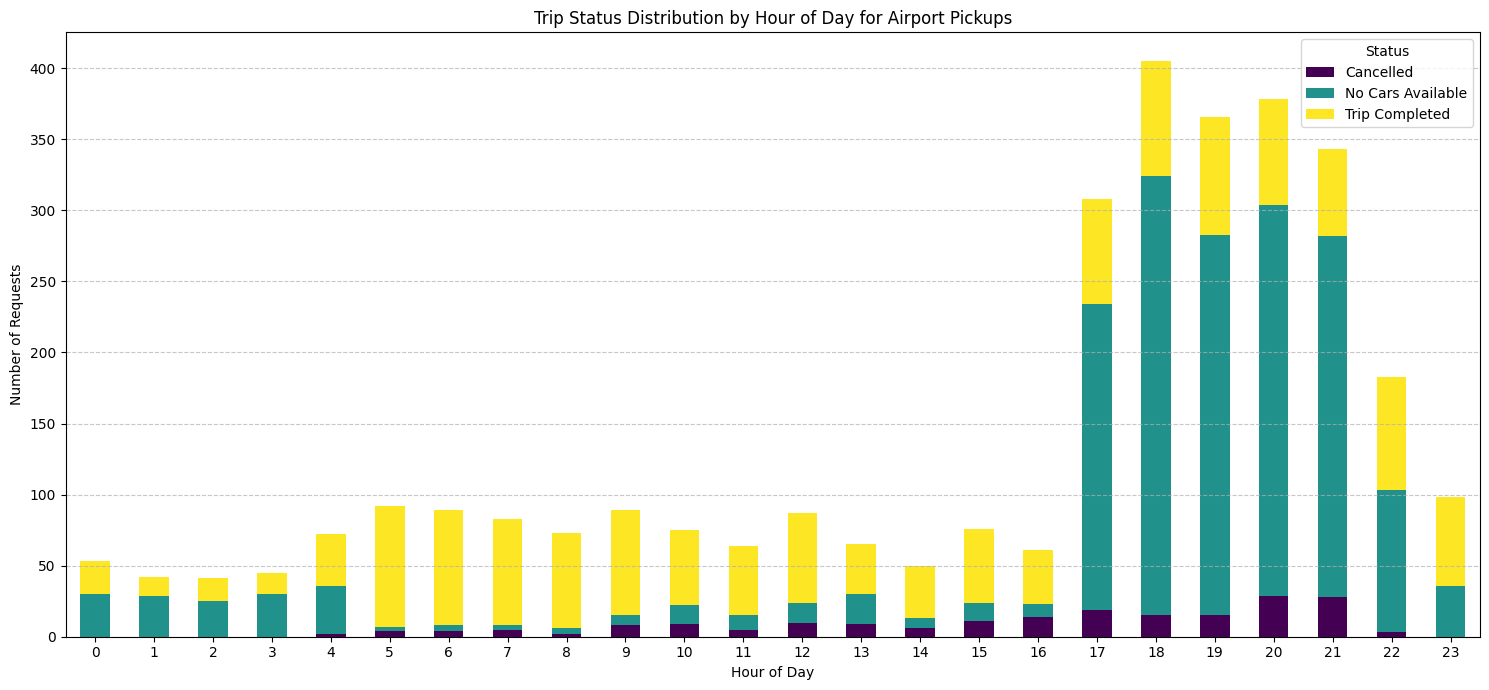

In [29]:
hourly_status_airport = df[df['Pickup point'] == 'Airport'].groupby(['RequestHour', 'Status'])['Request id'].count().unstack().fillna(0)
hourly_status_airport.plot(kind='bar', stacked=True, figsize=(15, 7), colormap='viridis')
plt.title('Trip Status Distribution by Hour of Day for Airport Pickups')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Requests')
plt.xticks(rotation=0)
plt.legend(title='Status')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()